# ISPU Jakarta — Skenario B
**Skenario B**: Data terbaru 2024 saja, **dengan fitur PM2.5** (kualitas fitur unggul ~3.4k baris)


## Tahap 1 — Setup Library & Load Data


In [2]:
import pandas as pd
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

DATA_DIR = Path(r".\dataset")

# Nama file yang ingin diambil
TARGET_FILE = "Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta - tabel.xls"

# Path lengkap file
file_path = DATA_DIR / TARGET_FILE

try:
    # Membaca tabel HTML dari file .xls
    df_baru = pd.read_html(file_path)[0]

    # Standarisasi nama kolom
    df_baru.columns = df_baru.columns.str.lower().str.strip()

    print(f"Berhasil memuat file: {TARGET_FILE}")
    print(f"Jumlah data: {df_baru.shape[0]} baris, {df_baru.shape[1]} kolom")

except Exception as e:
    print(f"Gagal memproses file: {e}")

Berhasil memuat file: Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta - tabel.xls
Jumlah data: 3501 baris, 13 kolom


## Tahap 2 — Data Cleaning & Imputasi


In [3]:
import numpy as np

print("=== TAHAP 2: DATA CLEANING & STANDARISASI ===\n")

# 1. Fungsi untuk menyeragamkan nama kolom (Versi Anti-Error Pandas Baru)
def standarisasi_kolom(df):
    kolom_mapping = {
        'wilayah': 'stasiun',
        'lokasi_spku': 'stasiun',
        'pm_sepuluh': 'pm10',
        'pm_duakomalima': 'pm25',
        'sulfur_dioksida': 'so2',
        'karbon_monoksida': 'co',
        'ozon': 'o3',
        'nitrogen_dioksida': 'no2',
        'parameter_pencemar_kritis': 'critical',
        'categori': 'kategori'
    }
    df_renamed = df.rename(columns=kolom_mapping)

    # Menggabungkan kolom yang memiliki nama kembar secara aman
    new_cols = {}
    for col in df_renamed.columns.unique():
        if isinstance(df_renamed[col], pd.DataFrame):
            # bfill(axis=1) akan menutupi NaN dengan data di kolom sebelahnya
            new_cols[col] = df_renamed[col].bfill(axis=1).iloc[:, 0]
        else:
            new_cols[col] = df_renamed[col]

    return pd.DataFrame(new_cols)

print("Standarisasi nama kolom...")
df_baru_clean = standarisasi_kolom(df_baru)

# 2. Fungsi pembersihan isi data (stasiun, polutan, dan target)
def clean_isi_data(df, is_baru=False):
    df = df.copy()

    # Standarisasi nama stasiun
    def bersihkan_stasiun(nama):
        nama = str(nama).upper()
        if 'DKI1' in nama: return 'DKI1'
        elif 'DKI2' in nama: return 'DKI2'
        elif 'DKI3' in nama: return 'DKI3'
        elif 'DKI4' in nama: return 'DKI4'
        elif 'DKI5' in nama: return 'DKI5'
        else: return np.nan

    df['stasiun'] = df['stasiun'].apply(bersihkan_stasiun)
    df = df.dropna(subset=['stasiun'])

    # Menentukan kolom polutan yang akan dibersihkan
    kolom_polutan = ['pm10', 'so2', 'co', 'o3', 'no2']
    if is_baru and 'pm25' in df.columns:
        kolom_polutan.append('pm25')  # PM2.5 khusus untuk data baru

    # Konversi ke angka desimal & Imputasi Median per stasiun
    for col in kolom_polutan:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df.groupby('stasiun')[col].transform(lambda x: x.fillna(x.median()))

    # Bersihkan target (kategori)
    df = df.dropna(subset=['kategori'])
    df['kategori'] = df['kategori'].astype(str).str.upper().str.strip()

    # Buang kelas ekstrem (BERBAHAYA) jika jumlahnya tidak signifikan
    kategori_valid = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT']
    df = df[df['kategori'].isin(kategori_valid)]

    # Buang kolom yang tidak perlu untuk modeling (Mencegah Data Leakage)
    kolom_buang = ['periode_data', 'tanggal', 'bulan', 'max', 'critical', 'source_file']
    df = df.drop(columns=[col for col in kolom_buang if col in df.columns])

    return df

print("Imputasi missing values dan perapihan isi data...")
df_baru_final = clean_isi_data(df_baru_clean, is_baru=True)

print("\n" + "="*50)
print("TAHAP CLEANING SELESAI")
print("="*50)
print(f"Bentuk Data BARU : {df_baru_final.shape[0]} baris.")
print(f"Kolom Data BARU  : {df_baru_final.columns.tolist()}")


=== TAHAP 2: DATA CLEANING & STANDARISASI ===

Standarisasi nama kolom...
Imputasi missing values dan perapihan isi data...

TAHAP CLEANING SELESAI
Bentuk Data BARU : 3480 baris.
Kolom Data BARU  : ['stasiun', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'kategori']


## Tahap 3 — EDA & Setup Skenario B


=== TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA) & SETUP SKENARIO B ===

Skenario B (termasuk PM2.5): 3480 baris



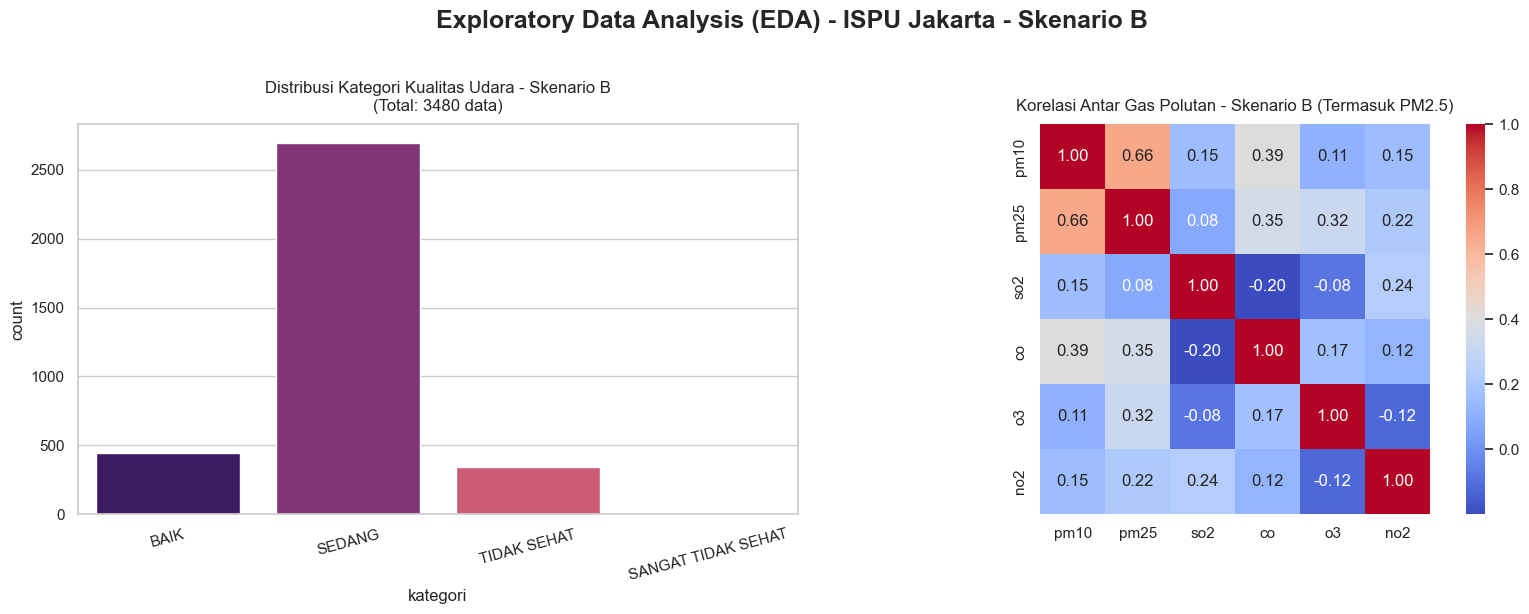

Visualisasi EDA disimpan sebagai 'eda_skenario_b.png'


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA) & SETUP SKENARIO B ===\n")

# 1. SETUP SKENARIO B
# Skenario B: Khusus data baru (punya PM2.5)
df_skenario_B = df_baru_final.copy()

print(f"Skenario B (termasuk PM2.5): {df_skenario_B.shape[0]} baris\n")

# 2. VISUALISASI EDA
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Exploratory Data Analysis (EDA) - ISPU Jakarta - Skenario B',
             fontsize=18, fontweight='bold', y=1.02)

# Grafik 1: Distribusi Target Skenario B
sns.countplot(data=df_skenario_B, x='kategori', ax=axes[0], palette='magma',
              order=['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT'])
axes[0].set_title(f'Distribusi Kategori Kualitas Udara - Skenario B\n(Total: {len(df_skenario_B)} data)', pad=10)
axes[0].tick_params(axis='x', rotation=15)

# Grafik 2: Heatmap Korelasi Polutan Skenario B
corr_B = df_skenario_B.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr_B, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1], square=True)
axes[1].set_title('Korelasi Antar Gas Polutan - Skenario B (Termasuk PM2.5)', pad=10)

plt.tight_layout()
nama_gambar_eda = 'eda_skenario_b.png'
plt.savefig(nama_gambar_eda, dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualisasi EDA disimpan sebagai '{nama_gambar_eda}'")


## Tahap 4 — Feature Engineering


In [5]:
print("=== TAHAP 4: FEATURE ENGINEERING ===\n")

def siapkan_fitur_target(df):
    df_copy = df.copy()

    # 1. Encoding Label Kategori (Ordinal)
    # Urutan dari yang paling sehat (0) ke paling bahaya (3)
    map_kategori = {'BAIK': 0, 'SEDANG': 1, 'TIDAK SEHAT': 2, 'SANGAT TIDAK SEHAT': 3}
    df_copy['kategori'] = df_copy['kategori'].map(map_kategori)

    # 2. One-Hot Encoding untuk Lokasi Stasiun
    # drop_first=True untuk menghindari jebakan statistik (dummy variable trap)
    df_copy = pd.get_dummies(df_copy, columns=['stasiun'], drop_first=True)

    # Konversi nilai boolean (True/False) hasil get_dummies menjadi angka murni (1/0)
    for col in df_copy.select_dtypes(include=['bool']).columns:
        df_copy[col] = df_copy[col].astype(int)

    # 3. Pisahkan Fitur (X) dan Target (y)
    X = df_copy.drop(columns=['kategori'])
    y = df_copy['kategori']

    return X, y

print("Memproses Skenario B (termasuk PM2.5)...")
X_B, y_B = siapkan_fitur_target(df_skenario_B)

print("Feature engineering selesai.")
print(f"Dimensi Skenario B -> X_B: {X_B.shape} | y_B: {y_B.shape}")

print("Cek 3 baris pertama X_B:")
display(X_B.head(3))


=== TAHAP 4: FEATURE ENGINEERING ===

Memproses Skenario B (termasuk PM2.5)...
Feature engineering selesai.
Dimensi Skenario B -> X_B: (3480, 10) | y_B: (3480,)
Cek 3 baris pertama X_B:


,pm10,pm25,so2,co,o3,no2,stasiun_DKI2,stasiun_DKI3,stasiun_DKI4,stasiun_DKI5
0,51.0,65.0,45.0,9.0,8.0,79.0,0,1,0,0
1,27.0,34.0,45.0,5.0,8.0,56.0,0,1,0,0
2,49.0,52.0,46.0,6.0,9.0,51.0,0,1,0,0


## Tahap 5 — Pemodelan & Pelatihan Random Forest


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("=== TAHAP 5: SPLIT DATA & PELATIHAN MODEL ===\n")

print("Memeriksa dan membersihkan kelas langka...")

# Filter Skenario B (Membuang kategori SANGAT TIDAK SEHAT yang cuma ada 1 data)
counts_B = y_B.value_counts()
kelas_valid_B = counts_B[counts_B >= 2].index

if len(counts_B) != len(kelas_valid_B):
    kelas_dibuang = counts_B[counts_B < 2].index.tolist()
    print(f"Catatan: Kelas indeks {kelas_dibuang} di Skenario B dikeluarkan")
    print(f"Karena sampel terlalu sedikit untuk dibagi ke data latih dan uji.")

X_B = X_B[y_B.isin(kelas_valid_B)]
y_B = y_B[y_B.isin(kelas_valid_B)]

# Pembagian data (Train-Test Split)
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=0.2, random_state=42, stratify=y_B
)

print(f"\nPembagian data berhasil:")
print(f"Skenario B -> Data latih: {X_train_B.shape[0]} baris | Data uji: {X_test_B.shape[0]} baris\n")

# Pelatihan Model
print("Mulai pelatihan Model Skenario B...")
model_B = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_B.fit(X_train_B, y_train_B)
print("Model B selesai dilatih.")

print("Pelatihan selesai tanpa error.")


=== TAHAP 5: SPLIT DATA & PELATIHAN MODEL ===

Memeriksa dan membersihkan kelas langka...
Catatan: Kelas indeks [3] di Skenario B dikeluarkan
Karena sampel terlalu sedikit untuk dibagi ke data latih dan uji.

Pembagian data berhasil:
Skenario B -> Data latih: 2783 baris | Data uji: 696 baris

Mulai pelatihan Model Skenario B...
Model B selesai dilatih.
Pelatihan selesai tanpa error.


## Tahap 6 — Evaluasi Model


=== TAHAP 6: EVALUASI MODEL SKENARIO B ===

SKOR AKURASI
Model Skenario B (Pakai PM2.5  | 3.4k Data): 98.99%

Report: Skenario B
              precision    recall  f1-score   support

        BAIK       1.00      0.93      0.97        89
      SEDANG       0.99      1.00      0.99       539
 TIDAK SEHAT       1.00      0.99      0.99        68

    accuracy                           0.99       696
   macro avg       1.00      0.97      0.98       696
weighted avg       0.99      0.99      0.99       696



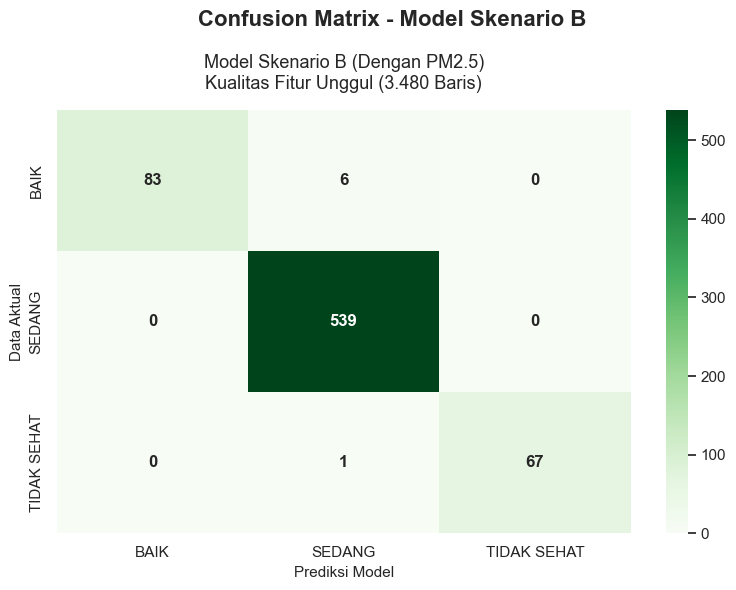

Grafik evaluasi disimpan sebagai 'evaluasi_model_b.png'


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("=== TAHAP 6: EVALUASI MODEL SKENARIO B ===\n")

# 1. Prediksi menggunakan Data Uji
y_pred_B = model_B.predict(X_test_B)

# target_names_B hanya 3 kelas karena SANGAT TIDAK SEHAT sudah di-drop di Cell 5
target_names_B = ['BAIK', 'SEDANG', 'TIDAK SEHAT']

# 2. Skor Akurasi
print("="*60)
print("SKOR AKURASI")
print("="*60)
print(f"Model Skenario B (Pakai PM2.5  | 3.4k Data): {accuracy_score(y_test_B, y_pred_B)*100:.2f}%")

# 3. Classification Report
print("\n" + "="*60)
print("Report: Skenario B")
print("="*60)
print(classification_report(y_test_B, y_pred_B, target_names=target_names_B))

# 4. Confusion Matrix
sns.set_theme(style="white")
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
fig.suptitle('Confusion Matrix - Model Skenario B', fontsize=16, fontweight='bold')

cm_B = confusion_matrix(y_test_B, y_pred_B)
sns.heatmap(cm_B, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=target_names_B, yticklabels=target_names_B,
            annot_kws={"size": 12, "weight": "bold"})
ax.set_title('Model Skenario B (Dengan PM2.5)\nKualitas Fitur Unggul (3.480 Baris)', pad=15, fontsize=13)
ax.set_xlabel('Prediksi Model', fontsize=11)
ax.set_ylabel('Data Aktual', fontsize=11)

plt.tight_layout()
nama_file_evaluasi = 'evaluasi_model_b.png'
plt.savefig(nama_file_evaluasi, dpi=300, bbox_inches='tight')
plt.show()

print(f"Grafik evaluasi disimpan sebagai '{nama_file_evaluasi}'")


## Tahap 8 — Stratified K-Fold Cross Validation


In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

print("=== TAHAP 8: VALIDASI (STRATIFIED K-FOLD) ===\n")
print("Menjalankan Stratified K-Fold (5 folds) untuk Skenario B...")
print("Proses akan mengukur akurasi pada setiap fold.\n")

# 1. Definisi Stratified K-Fold secara tegas (Shuffle=True agar data diacak merata)
cv_strategi = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Menghitung skor akurasi di setiap lipatan menggunakan seluruh data Skenario B (X_B, y_B)
skor_folds = cross_val_score(model_B, X_B, y_B, cv=cv_strategi, scoring='accuracy')

# 3. Menampilkan Output Analisis
print("="*60)
print("Laporan cross-validation")
print("="*60)
for i, skor in enumerate(skor_folds, start=1):
    print(f"Akurasi fold {i}: {skor*100:.2f}%")

print("-"*60)
print(f"Rata-rata akurasi: {skor_folds.mean()*100:.2f}%")
print(f"Standar deviasi: {skor_folds.std()*100:.4f}%")
print("="*60)

# 4. Kesimpulan Otomatis untuk Bahan Bab Pembahasan Laporan
if skor_folds.mean() >= 0.95 and skor_folds.std() < 0.02:
    print("\nKesimpulan validasi: Model stabil dan akurat.")
    print(f"Rata-rata akurasi: {skor_folds.mean()*100:.2f}% (std: {skor_folds.std()*100:.2f}%)")
    print("Hasil ini menunjukkan konsistensi performa berdasarkan cross-validation.")
else:
    print("\nKesimpulan validasi: Model menunjukkan fluktuasi akurasi.")


=== TAHAP 8: VALIDASI (STRATIFIED K-FOLD) ===

Menjalankan Stratified K-Fold (5 folds) untuk Skenario B...
Proses akan mengukur akurasi pada setiap fold.

Laporan cross-validation
Akurasi fold 1: 98.13%
Akurasi fold 2: 98.71%
Akurasi fold 3: 98.85%
Akurasi fold 4: 97.99%
Akurasi fold 5: 98.85%
------------------------------------------------------------
Rata-rata akurasi: 98.51%
Standar deviasi: 0.3699%

Kesimpulan validasi: Model stabil dan akurat.
Rata-rata akurasi: 98.51% (std: 0.37%)
Hasil ini menunjukkan konsistensi performa berdasarkan cross-validation.


In [ ]:
# ==========================================
# CELL 9: SIMULASI PREDIKSI DATA UDARA BARU
# ==========================================
import pandas as pd
import numpy as np

print("=== SIMULASI PREDIKSI DATA BARU ===\n")

# Mapping kategori (sama dengan yang dipakai saat training)
map_kategori = {'BAIK': 0, 'SEDANG': 1, 'TIDAK SEHAT': 2}
map_kategori_terbalik = {v: k for k, v in map_kategori.items()}

# Data simulasi: [pm10, pm25, so2, co, o3, no2]
# Skenario B menyertakan PM2.5 sebagai fitur tambahan
data_baru = [
    [25.0,  30.0, 12.0,  6.0,  15.0,  8.0],  
    [55.0,  70.0, 25.0, 10.0,  55.0, 15.0],  
    [75.0,  95.0, 30.0, 15.0, 100.0, 20.0],  
    [85.0, 120.0, 35.0, 18.0, 130.0, 25.0],  
]

kolom_polutan_b = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
df_simulasi = pd.DataFrame(data_baru, columns=kolom_polutan_b)

# Tambahkan kolom one-hot stasiun (semua 0 = stasiun DKI1 sebagai referensi)
# Urutan kolom harus PERSIS sama seperti saat model dilatih
for col in ['stasiun_DKI2', 'stasiun_DKI3', 'stasiun_DKI4', 'stasiun_DKI5']:
    df_simulasi[col] = 0

# Pastikan urutan kolom sama persis dengan X_B yang dipakai training
df_simulasi = df_simulasi[X_B.columns]

print("Data simulasi yang diinput ke model:")
print(df_simulasi[kolom_polutan_b].to_string(index=False))
print()

# Prediksi
prediksi_kategori      = model_B.predict(df_simulasi)
prediksi_kategori_nama = [map_kategori_terbalik[kode] for kode in prediksi_kategori]

# Tampilkan hasil
df_hasil = pd.DataFrame(data_baru, columns=kolom_polutan_b)
df_hasil['Prediksi Kategori'] = prediksi_kategori_nama

print("=== HASIL PREDIKSI ===")
print(df_hasil.to_string(index=False))

=== SIMULASI PREDIKSI DATA BARU ===

Data simulasi yang diinput ke model:
 pm10  pm25  so2   co    o3  no2
 25.0  30.0 12.0  6.0  15.0  8.0
 55.0  70.0 25.0 10.0  55.0 15.0
 75.0  95.0 30.0 15.0 100.0 20.0
 85.0 120.0 35.0 18.0 130.0 25.0

=== HASIL PREDIKSI ===
 pm10  pm25  so2   co    o3  no2 Prediksi Kategori
 25.0  30.0 12.0  6.0  15.0  8.0              BAIK
 55.0  70.0 25.0 10.0  55.0 15.0            SEDANG
 75.0  95.0 30.0 15.0 100.0 20.0            SEDANG
 85.0 120.0 35.0 18.0 130.0 25.0       TIDAK SEHAT


=== VISUALISASI PROBABILITAS PREDIKSI ===

Grafik disimpan: 'visualisasi_prediksi_skenario_b.png'


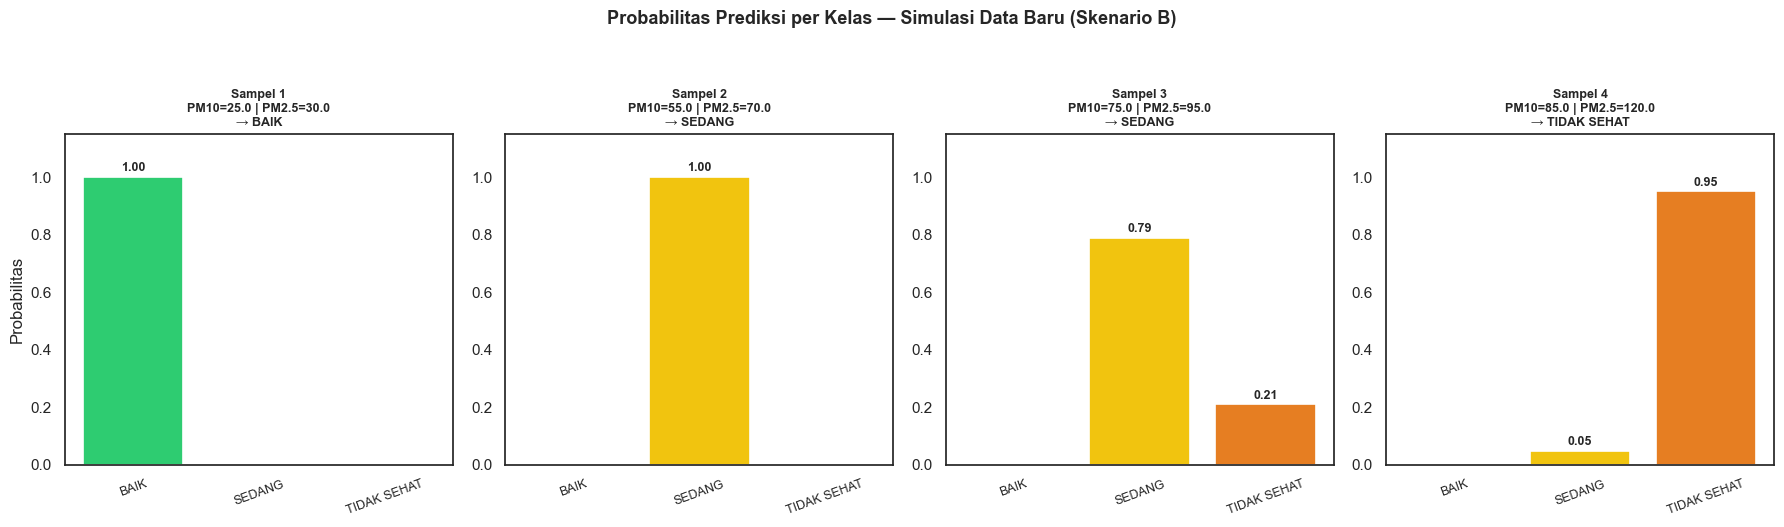

In [10]:
# ==========================================
# CELL 10: VISUALISASI PROBABILITAS PREDIKSI
# ==========================================
import matplotlib.pyplot as plt

print("=== VISUALISASI PROBABILITAS PREDIKSI ===\n")

# Hitung probabilitas tiap kelas untuk setiap sampel
y_proba_new = model_B.predict_proba(df_simulasi)

# Nama kelas berdasarkan yang dipelajari model (hanya 3 kelas)
present_class_names = [map_kategori_terbalik[c] for c in model_B.classes_]

# Warna per kelas: BAIK=hijau, SEDANG=kuning, TIDAK SEHAT=oranye
colors_prob = ['#2ecc71', '#f1c40f', '#e67e22']
colors_mapped = [colors_prob[c] for c in model_B.classes_]

# Buat subplots berjajar sebanyak jumlah sampel
fig, axes = plt.subplots(1, len(df_hasil), figsize=(18, 5))

for i, (proba, pred) in enumerate(zip(y_proba_new, prediksi_kategori)):
    axes[i].bar(present_class_names, proba,
                color=colors_mapped, edgecolor='white', linewidth=1.2)

    axes[i].set_title(
        f'Sampel {i+1}\n'
        f'PM10={data_baru[i][0]} | PM2.5={data_baru[i][1]}\n'
        f'→ {map_kategori_terbalik[pred]}',
        fontsize=9, fontweight='bold'
    )
    axes[i].set_ylim(0, 1.15)
    axes[i].set_ylabel('Probabilitas' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=20, labelsize=9)

    # Tampilkan angka probabilitas di atas batang (jika > 3%)
    for j, p in enumerate(proba):
        if p > 0.03:
            axes[i].text(j, p + 0.02, f'{p:.2f}',
                         ha='center', fontsize=9, fontweight='bold')

plt.suptitle(
    'Probabilitas Prediksi per Kelas — Simulasi Data Baru (Skenario B)',
    fontsize=13, fontweight='bold', y=1.05
)
plt.tight_layout()

nama_plot = 'visualisasi_prediksi_skenario_b.png'
plt.savefig(nama_plot, dpi=150, bbox_inches='tight')
print(f"Grafik disimpan: '{nama_plot}'")
plt.show()